In [1]:
# %uv pip install setuptools scikit-learn pandas azureml-core seaborn shap

# Simple Explanation for Leadership (30-Second Version)

This notebook demonstrates how AI can help detect credit card fraud.
The process works as follows:
1.	Historical transaction data is collected.
2.	A machine learning model learns what normal transactions look like.
3.	The system identifies transactions that behave abnormally.
4.	Suspicious transactions are flagged automatically.
5.	The model can be deployed to monitor transactions in real time.
Business value
•	faster fraud detection
•	reduced financial loss
•	scalable monitoring of millions of transactions
•	improved security automation


## Workflow

### Step 1: import the PyPi packages


### Step 1: import the PyPi packages
The first part of the code prepares the working environment.
Actions include:
•	loading Python libraries
•	connecting to the Azure Machine Learning workspace
•	setting up the computing environment
Business meaning
This step connects the project to a secure cloud AI platform where models can be trained and deployed.

<img src="IMG_0631.png" alt="IMG_0631.png" width="120"/>

In [2]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # see https://pypi.org/project/azureml-core/
import pandas as pd                                 # see https://pandas.pydata.org/docs/
from sklearn.ensemble import IsolationForest        # see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
from sklearn.metrics import classification_report   # see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
from azureml.core.model import Model                # see https://docs.microsoft.com/en-us/python/api/azureml-core/azureml.core.model?view=azure-ml-py 

### Step 2: Load the Credit Card Fraud Dataset from Azure ML

The notebook loads a dataset containing transaction records.
Typical information in the dataset:
•	transaction amount
•	time of transaction
•	anonymized card behavior features
•	label indicating fraud or legitimate transaction
In fraud datasets:
•	~99.8% transactions are normal
•	~0.2% are fraudulent
Business meaning
The system learns from historical data to understand what normal activity looks like.




In [3]:
# You only need to run this if you've imported this notebook to Azure AI Machine Learning Studio - Notebook,
# in which case you'll also need to upload the config.json file to the same directory as this notebook,
# and then execute this code to determine the current working directory.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())


Current working directory: C:\UBC\ML_AI\AI_Training\Data_literacy-2\CapStone\azureml-example\jupyter
Files in this directory: ['.ipynb_checkpoints', 'anomaly_detection_creditcard_bak.ipynb', 'anomaly_detection_creditcard_EDBI_Team.ipynb', 'anomaly_detection_creditcard_Stan.ipynb', 'House_Prices_Regression_Demo.ipynb', 'IMG_0631.jpeg', 'IMG_0631.png', 'isolation_forest.pkl', 'k-means.ipynb', 'requirements.txt']


In [4]:
# if you're running locally then use this ...
path = None
df = pd.read_csv('C:/UBC/ML_AI/AI_Training/Data_literacy-1/Datasets/Credit_Card/creditcard.csv')
df.head()
#### alternatively, if you're running in Azure AI Machine Learning Studio - Notebook, then use this ...
#### (make sure to upload the config.json file to the same directory as this notebook)
####  and then execute this code to determine the current working directory.
# path='Users/[REPLACE-THIS-WITH-YOUR-USERNAME]/config.json'
# ws = Workspace.from_config(path=path)
# dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
# df = dataset.to_pandas_dataframe()
# df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Step 3: Prepare the Data

The notebook loads a dataset containing transaction records.
Typical information in the dataset:
•	transaction amount
•	time of transaction
•	anonymized card behavior features
•	label indicating fraud or legitimate transaction
In fraud datasets:
•	~99.8% transactions are normal
•	~0.2% are fraudulent
Business meaning
The system learns from historical data to understand what normal activity looks like.
Data preparation steps may include:
•	separating fraud vs non-fraud labels
•	scaling numeric variables
•	splitting the dataset into training and testing sets
Typical split:
Dataset	Purpose
Training data	Teach the model patterns
Test data	Measure prediction accuracy
Business meaning
This step ensures the model is tested on data it has never seen before, which verifies reliability.


In [5]:
df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

### Step 4: Train the model

The machine learning algorithm is trained to identify patterns that do not fit normal transaction behavior.
Instead of learning “fraud examples,” the system learns:
what normal transactions look like
Then it flags anything statistically different.
This approach works well when fraud examples are rare.
Business meaning
The AI becomes a pattern recognition system that monitors transactions automatically.


In [6]:
model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

### Step 5: Evaluating the Anomaly Detection Model

The table below is a summary of metrics that are calculated from the [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix). It shows how well our model identified normal and fraudulent transactions:

| Metric       | What It Means                                                                 |
|--------------|--------------------------------------------------------------------------------|
| **Precision** | How often the model was *correct* when it said a transaction was fraud        |
| **Recall**    | How many of the *actual fraud cases* the model successfully found             |
| **F1-Score**  | A balance between precision and recall — like a combined performance score     |
| **Support**   | The number of examples in each group (normal or fraud) in the real data        |

#### Results Summary

| Class | Description           | Precision | Recall | F1-Score | Support |
|-------|------------------------|-----------|--------|----------|---------|
| `0`   | Normal transactions    | **1.00**  | **1.00** | **1.00**   | 284,315 |
| `1`   | Fraudulent transactions| **0.29**  | **0.28** | **0.28**   | 492     |

#### Interpretation (In Simple Terms)

The notebook evaluates how well the model detects fraud.
Typical evaluation metrics include:
•	Precision (how many alerts are actually fraud)
•	Recall (how many fraud cases were detected)
•	Accuracy
Business meaning
Executives need to know:
•	How many fraud cases will be caught
•	How many false alerts will occur
This helps balance security vs customer experience.


In [7]:
# Step 5: Evaluate Model
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



### step 6 Operational deployment
In a real production system, the trained model would be:
•	registered in Azure ML studio or other AI/ML platform
•	deployed as a real-time API service
Other systems (payment gateways, fraud monitoring tools) send transactions to the model for evaluation.
Business meaning
This converts the AI model into a live fraud detection service used during payment processing.


In [8]:
#### below is save and rester model in Azure AI Machine Learning Studio - Notebook
# import joblib                                       # see https://joblib.readthedocs.io/en/latest/
#                                                     #     Joblib is a set of tools to provide lightweight pipelining in Python
# joblib.dump(model, 'isolation_forest.pkl')
# Model.register(model_path='isolation_forest.pkl',
#                model_name='creditcard_if_model',
#                workspace=ws)


### Step 7: Visualize a Count of Predicted Anomalies

7. Identify Suspicious Transactions
Once the model runs, the system produces a risk score for each transaction.
Example:
Transaction	Risk Score	Flag
$15 grocery purchase	Low	Normal
$4,500 overseas purchase	High	Suspicious
Transactions with high anomaly scores are flagged for:
•	automated blocking
•	additional verification
•	fraud investigation

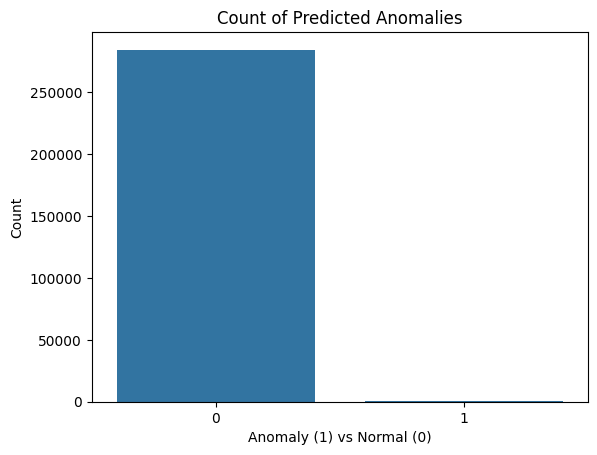

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add predictions to the original dataframe
df['predicted_anomaly'] = y_pred

# Count of predicted anomalies
sns.countplot(x='predicted_anomaly', data=df)
plt.title('Count of Predicted Anomalies')
plt.xlabel('Anomaly (1) vs Normal (0)')
plt.ylabel('Count')
plt.show()


### Step 7 (continued): Visualize Transaction Amount by Prediction Class

The boxplot below compares the **amount of money** in transactions that the model predicted as **normal (0)** or **anomalous/fraud (1)**.

- **X-axis**: The model’s prediction.
  - `0` = predicted normal transaction
  - `1` = predicted fraud/anomaly
- **Y-axis**: The dollar **amount** of each transaction (standardized)

#### How to Interpret This Chart

- Each box shows how transaction amounts are distributed for each prediction class.
- The **line in the middle** of each box is the **median** transaction amount.
- The **height of the box** shows where most transaction amounts fall.
- **Dots outside the box** are **outliers** — unusual values far from the average.

#### What This Tells Us

- You may see that predicted frauds (`1`) tend to have **more extreme** or **variable amounts**.
- This could suggest that the model is flagging **unusually high or low transaction amounts** as suspicious.
- If the fraud predictions have a **much wider range**, it means the model may be reacting to extreme values — which is common in anomaly detection.

#### Usefulness
  
*Accessible description: Two neon yellow soccer cleats with untied laces are placed side by side on a light brown wooden floor indoors. The shoes are clean and facing upward, with no people present. The scene feels casual and practical, like sports gear set down after use. No visible text appears in the image.*

This chart helps you:
- Understand what kinds of amounts the model thinks are suspicious.
- Spot any bias in the model (e.g. only flagging large transactions).
- Decide whether you need to normalize, transform, or engineer features differently.

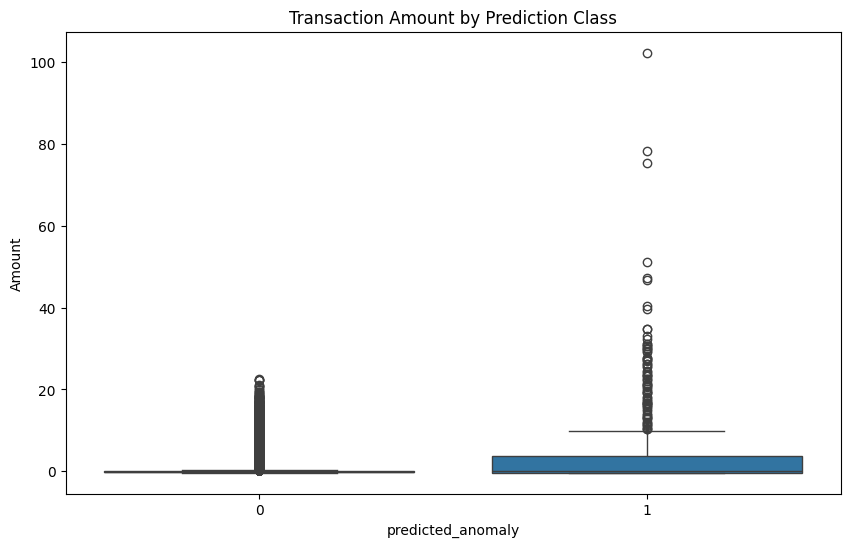

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()


### Step 7 (continued): SHAP Beeswarm Plot – Feature Importance for Anomaly Detection

The beeswarm plot below is generated using **SHAP** (SHapley Additive exPlanations). It helps explain **which features influenced the model's decisions**, and **how strongly**. We only analyze the first 100 transactions here in order to keep the visualization fast and readable.

#### How to Read the SHAP Beeswarm Plot

- **Each dot** represents a single transaction.
- **Each row** is one feature (like `V1`, `V2`, `Amount`, etc.).
- **Color** shows the feature value for that transaction:
  - **Red = high** value
  - **Blue = low** value
- **Horizontal position** shows **impact on the model’s prediction**:
  - Dots farther to the right **push the model toward predicting fraud**.
  - Dots farther to the left **push the model toward predicting normal**.

#### What This Tells Us

- The **topmost features** are the most important ones in the model’s decisions.
- For example, if `V14` is at the top and its red dots are far right, it means:
  - High values of `V14` increase the chance that the model flags a transaction as fraud.
- This plot helps us understand **why** the model flagged certain transactions as anomalies.

#### Why Use SHAP?

- SHAP adds transparency to the model, even for complex algorithms like Isolation Forest.
- Helps **build trust**, especially in sensitive tasks like fraud detection.
- Guides feature selection and **future model improvements**.

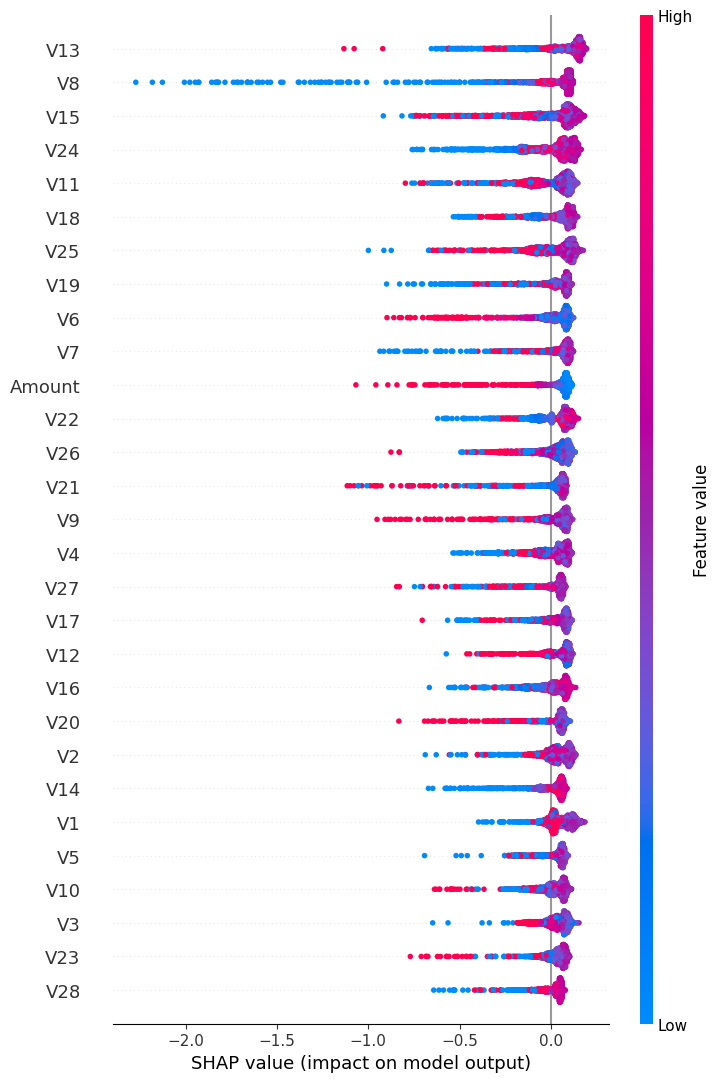

In [11]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:2000])
# shap.plots.beeswarm(shap_values
#                     , max_display=10
#                    , show=False
#                    )
# Display all features in the beeswarm plot
shap.plots.beeswarm(shap_values, max_display=X.shape[1])
